# High-$N_2O$ Event Classification for a Single WWTP Time-Series Segment

This notebook builds a complete, leakage-aware classification workflow for identifying high next-step $N_2O$ events from a single preprocessed wastewater treatment plant segment.

The continuous modelling target provided in the dataset is:

- `Target_N2O_t+1`

The classification target is created by thresholding `Target_N2O_t+1`, so the task becomes:

> Does the **next-step** $N_2O$ value exceed a chosen threshold?

## Key design choices

- The data are already preprocessed, so this notebook performs only essential checks and minimal task-specific preprocessing.
- Time order is preserved throughout.
- Threshold definition is treated as an explicit modelling decision, because temporal distribution shift may make some threshold strategies unstable across train/validation/test.

## What this notebook does

1. Loads the segment CSV from a path variable.
2. Parses `time` as timezone-aware datetime and sorts chronologically.
3. Performs minimal validation and essential preprocessing only.
4. Creates binary classification labels from `Target_N2O_t+1`.
5. Compares several thresholding strategies.
6. Reports class balance by split for each strategy.
7. Trains several leakage-safe classification models.
8. Tunes the **decision cutoff** on validation rather than relying only on 0.5.
9. Evaluates on a held-out test set using class-imbalance-aware metrics.
10. Produces diagnostic visualisations and a compact interpretation.

In [1]:
# =========================
# 1. Imports and settings
# =========================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier



RANDOM_STATE = 42
N_SPLITS_INNER_CV = 4

# -------------------------
# User-configurable path
# -------------------------
DATA_PATH = r"C:\Users\tomor\Documents\MSc Lecture Notes\Data Science Project\EDS_Design_Project\data\segment_data\seg4_df_features_10lags_ready.csv"

# Preferred chronological split
TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
TEST_FRAC = 0.20

# Candidate percentile thresholds
CANDIDATE_PERCENTILES = [90.0, 95.0]

# Validation decision-threshold grid
DECISION_THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.05), 2)
DECISION_THRESHOLD_GRID2 = np.round(np.arange(0.01, 0.21, 0.01), 2)

print("Notebook settings loaded.")
print(f"Data path: {DATA_PATH}")

Notebook settings loaded.
Data path: C:\Users\tomor\Documents\MSc Lecture Notes\Data Science Project\EDS_Design_Project\data\segment_data\seg4_df_features_10lags_ready.csv


In [2]:
from matplotlib.colors import LinearSegmentedColormap

# ---------- Visual identity ----------
IMPERIAL_BLUE = "#1036DD"

color_map = {
    # Hydraulic / operational
    "inflow": "#001489",
    "total_airflow": "#003E74",
    "t1_airflow": "#2B8CBE",

    # Nitrogen species
    "t1_n2o": "#D50032",
    "t1_nh4": "#960058",
    "t1_no3": "#653098",

    # Process conditions
    "t1_do": "#00AEEF",

    # Solids
    "t1_ss": "#6D6E71",

    # Temperature
    "t1_temp": "#E87722",

    # Phosphorus
    "t1_po4": "#00A651"
}

label_map = {
    "t1_n2o": "N2O",
    "t1_nh4": "NH4",
    "t1_no3": "NO3",
    "t1_do": "DO",
    "t1_airflow": "Tank 1 airflow",
    "t1_temp": "Temperature",
    "total_airflow": "Total airflow",
    "t1_do_sp": "DO setpoint",
    "t1_ss": "Suspended solids",
    "t1_po4": "PO4",
    "inflow": "Inflow",
    "t1_valve_pct": "Valve position"
}

imperial_seq = LinearSegmentedColormap.from_list(
    "imperial_seq", ["#F7F9FF", IMPERIAL_BLUE]
)
imperial_div = LinearSegmentedColormap.from_list(
    "imperial_div", ["#D50032", "#FFFFFF", IMPERIAL_BLUE]
)
plt.rcParams["figure.dpi"] = 120
def feature_color(name: str) -> str:
    return color_map.get(name, IMPERIAL_BLUE)

def pretty_label(name: str) -> str:
    return label_map.get(name, name)

def bar_colors(labels):
    return [feature_color(lbl) for lbl in labels]

In [3]:
# ==========================================
# 2. Expected columns and essential loading
# ==========================================

required_columns = [
    "time","t1_nh4","t1_no3","t1_airflow","t1_temp","t1_po4","inflow","Target_N2O_t+1",
    "t1_nh4_lag_1","t1_nh4_lag_2","t1_nh4_lag_3","t1_nh4_lag_4","t1_nh4_lag_5","t1_nh4_lag_6","t1_nh4_lag_7","t1_nh4_lag_8","t1_nh4_lag_9","t1_nh4_lag_10",
    "t1_no3_lag_1","t1_no3_lag_2","t1_no3_lag_3","t1_no3_lag_4","t1_no3_lag_5","t1_no3_lag_6","t1_no3_lag_7","t1_no3_lag_8","t1_no3_lag_9","t1_no3_lag_10",
    "t1_airflow_lag_1","t1_airflow_lag_2","t1_airflow_lag_3","t1_airflow_lag_4","t1_airflow_lag_5","t1_airflow_lag_6","t1_airflow_lag_7","t1_airflow_lag_8","t1_airflow_lag_9","t1_airflow_lag_10",
    "t1_temp_lag_1","t1_temp_lag_2","t1_temp_lag_3","t1_temp_lag_4","t1_temp_lag_5","t1_temp_lag_6","t1_temp_lag_7","t1_temp_lag_8","t1_temp_lag_9","t1_temp_lag_10",
    "t1_po4_lag_1","t1_po4_lag_2","t1_po4_lag_3","t1_po4_lag_4","t1_po4_lag_5","t1_po4_lag_6","t1_po4_lag_7","t1_po4_lag_8","t1_po4_lag_9","t1_po4_lag_10",
    "inflow_lag_1","inflow_lag_2","inflow_lag_3","inflow_lag_4","inflow_lag_5","inflow_lag_6","inflow_lag_7","inflow_lag_8","inflow_lag_9","inflow_lag_10"
]

feature_columns = [c for c in required_columns if c not in ["time", "Target_N2O_t+1"]]
target_col = "Target_N2O_t+1"
time_col = "time"

path_obj = Path(DATA_PATH)
if not path_obj.exists():
    raise FileNotFoundError(f"CSV not found at: {DATA_PATH}")

df = pd.read_csv(path_obj)

print(f"Loaded dataset with shape: {df.shape}")

missing_required = [c for c in required_columns if c not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

# Keep only required columns in the expected order for clarity and portability
df = df[required_columns].copy()

# Parse time and sort
df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")
if df[time_col].isna().any():
    n_bad = int(df[time_col].isna().sum())
    raise ValueError(f"{n_bad} rows have unparseable timestamps in '{time_col}'.")

df = df.sort_values(time_col).reset_index(drop=True)

# Ensure predictors/target are numeric where needed
for col in feature_columns + [target_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Data loaded and minimally validated.")
print(f"Time span: {df[time_col].min()} to {df[time_col].max()}")
print(f"Number of feature columns: {len(feature_columns)}")
display(df.head())

Loaded dataset with shape: (18276, 90)
Data loaded and minimally validated.
Time span: 2024-02-05 20:30:00+00:00 to 2024-06-11 21:40:00+00:00
Number of feature columns: 66


,time,t1_nh4,t1_no3,t1_airflow,t1_temp,t1_po4,inflow,Target_N2O_t+1,t1_nh4_lag_1,t1_nh4_lag_2,...,inflow_lag_1,inflow_lag_2,inflow_lag_3,inflow_lag_4,inflow_lag_5,inflow_lag_6,inflow_lag_7,inflow_lag_8,inflow_lag_9,inflow_lag_10
0,2024-02-05 20:30:00+00:00,3.984539,0.934137,5599.373553,11.551107,0.977083,9415.218506,0.045370,4.051944,6.356849,...,10767.583594,9768.232861,10220.388574,9148.764111,9158.052002,9189.333447,8725.659858,8469.878662,8092.274463,8597.678698
1,2024-02-05 20:40:00+00:00,4.017338,1.274074,4229.927241,11.553096,0.735477,10247.750293,0.056019,3.984539,4.051944,...,9415.218506,10767.583594,9768.232861,10220.388574,9148.764111,9158.052002,9189.333447,8725.659858,8469.878662,8092.274463
2,2024-02-05 20:50:00+00:00,2.732623,1.636445,4965.339522,11.547852,0.549337,10548.768262,0.069792,4.017338,3.984539,...,10247.750293,9415.218506,10767.583594,9768.232861,10220.388574,9148.764111,9158.052002,9189.333447,8725.659858,8469.878662
3,2024-02-05 21:00:00+00:00,2.463306,1.738025,5092.059049,11.542426,0.475455,9720.215283,0.077083,2.732623,4.017338,...,10548.768262,10247.750293,9415.218506,10767.583594,9768.232861,10220.388574,9148.764111,9158.052002,9189.333447,8725.659858
4,2024-02-05 21:10:00+00:00,3.164398,2.098161,4555.645102,11.534108,0.464478,10113.823389,0.094329,2.463306,2.732623,...,9720.215283,10548.768262,10247.750293,9415.218506,10767.583594,9768.232861,10220.388574,9148.764111,9158.052002,9189.333447


## Essential preprocessing only

Because the dataset is already cleaned, this notebook does **not** redo broad cleaning or feature engineering.

Only minimal task-specific handling is applied:

- rows with missing `Target_N2O_t+1` are removed, because the target must exist to create labels;
- remaining feature missingness is handled inside model pipelines using an imputer;
- the original provided predictors are kept as they are.

In [4]:
# ============================================
# 3. Essential preprocessing for this task
# ============================================

initial_n = len(df)

# Drop rows with missing target only, since classification labels cannot be created without it
df = df.loc[df[target_col].notna()].copy()

removed_target_na = initial_n - len(df)
print(f"Rows removed due to missing {target_col}: {removed_target_na}")

# Check feature missingness but do not broadly clean; model pipeline will impute as needed
feature_missing_summary = (
    df[feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("Top feature missing-value counts:")
display(feature_missing_summary.head(10))

print(f"Remaining dataset shape after essential preprocessing: {df.shape}")

Rows removed due to missing Target_N2O_t+1: 0
Top feature missing-value counts:


t1_nh4          0
t1_no3          0
t1_airflow      0
t1_temp         0
t1_po4          0
inflow          0
t1_nh4_lag_1    0
t1_nh4_lag_2    0
t1_nh4_lag_3    0
t1_nh4_lag_4    0
dtype: int64

Remaining dataset shape after essential preprocessing: (18276, 68)


## Chronological split

A fixed chronological split is used:

- first 60%: training
- next 20%: validation
- final 20%: test

This matches the requested structure and preserves time ordering.

In [5]:
# ============================
# 4. Chronological train/val/test split
# ============================

def chronological_split(df, train_frac=0.60, val_frac=0.2):
    n = len(df)
    train_end = int(np.floor(n * train_frac))
    val_end = int(np.floor(n * (train_frac + val_frac)))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

train_df, val_df, test_df = chronological_split(df, TRAIN_FRAC, VAL_FRAC)

print("Chronological split sizes:")
print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

print("\nTime ranges by split:")
print(f"Train: {train_df[time_col].min()} -> {train_df[time_col].max()}")
print(f"Val:   {val_df[time_col].min()} -> {val_df[time_col].max()}")
print(f"Test:  {test_df[time_col].min()} -> {test_df[time_col].max()}")

assert train_df[time_col].max() <= val_df[time_col].min()
assert val_df[time_col].max() <= test_df[time_col].min()

Chronological split sizes:
Train: (10965, 68)
Validation: (3655, 68)
Test: (3656, 68)

Time ranges by split:
Train: 2024-02-05 20:30:00+00:00 -> 2024-04-22 01:10:00+00:00
Val:   2024-04-22 01:20:00+00:00 -> 2024-05-17 10:20:00+00:00
Test:  2024-05-17 10:30:00+00:00 -> 2024-06-11 21:40:00+00:00


We preserved time order throughout, since the task is predictive and future observations should not inform model fitting. However, because high-$N_2O$ events are rare and their prevalence varies over time, split boundaries were checked to ensure that train, validation, and test each contained a suitable proportion of positive cases. This was done to support meaningful classifier training and evaluation, not to enforce identical class distributions across splits. Residual differences in event prevalence were retained and reported as part of the temporal drift assessment. However, because the split design is informed by the observed distribution of the target, it implicitly assumes that the event prevalence seen in this dataset is a useful guide to future class balance; in practice, if the underlying data-generating process is non-stationary and the frequency of high-$N_2O$ episodes shifts over time, this may lead to an evaluation setup that is less representative of true out-of-sample deployment performance.

## Thresholding strategies

A major modelling choice here is how to define **high $N_2O$** for classification.

This notebook compares several simple and interpretable strategies.

### 1. Training-percentile thresholds
Thresholds are computed from the **training** portion only, for example the 90th and 95th percentiles of `Target_N2O_t+1` in the training set.

This is the most leakage-conscious option for a predictive workflow, because the threshold is defined without looking into future periods.

### 2. Full-segment percentile thresholds
Thresholds are computed from the **entire segment**. These are included only for **sensitivity analysis**, not as the primary predictive choice.

They can be useful for understanding how much of the apparent imbalance problem is caused by threshold definition itself. However, they are not strictly forecasting-pure because they use future information when setting the event boundary.

For each strategy, the notebook reports:
- threshold value,
- event rate in train/validation/test,
- whether the strategy produces very severe imbalance or obvious temporal drift.

In [6]:
# =====================================
# 5. Threshold strategy construction
# =====================================

def build_threshold_strategies(train_target, full_target, candidate_percentiles=(90.0, 95.0)):
    strategies = []

    # Training-only percentiles: main predictive thresholds
    for p in candidate_percentiles:
        threshold = np.percentile(train_target, p)
        strategies.append({
            "strategy_name": f"train_percentile_{p:g}",
            "strategy_group": "train_percentile",
            "threshold_source": "train_only",
            "rule_description": f"{p:g}th percentile of training Target_N2O_t+1",
            "threshold_value": float(threshold)
        })

    # Full-segment percentiles: sensitivity analysis only
    for p in candidate_percentiles:
        threshold = np.percentile(full_target, p)
        strategies.append({
            "strategy_name": f"full_percentile_{p:g}",
            "strategy_group": "full_percentile_sensitivity",
            "threshold_source": "full_segment",
            "rule_description": f"{p:g}th percentile of full-segment Target_N2O_t+1",
            "threshold_value": float(threshold)
        })

    return pd.DataFrame(strategies)

threshold_strategies = build_threshold_strategies(
    train_target=train_df[target_col].values,
    full_target=df[target_col].values,
    candidate_percentiles=CANDIDATE_PERCENTILES
)

display(threshold_strategies)

,strategy_name,strategy_group,threshold_source,rule_description,threshold_value
0,train_percentile_90,train_percentile,train_only,90th percentile of training Target_N2O_t+1,0.378148
1,train_percentile_95,train_percentile,train_only,95th percentile of training Target_N2O_t+1,0.482153
2,full_percentile_90,full_percentile_sensitivity,full_segment,90th percentile of full-segment Target_N2O_t+1,0.337616
3,full_percentile_95,full_percentile_sensitivity,full_segment,95th percentile of full-segment Target_N2O_t+1,0.456597


In [7]:
# ==========================================
# 6. Class balance under each threshold rule
# ==========================================

def binary_label(series, threshold):
    return (series > threshold).astype(int)

def get_class_weight_dict(y):
    classes = np.array([0, 1])
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {0: weights[0], 1: weights[1]}

def get_sample_weights(y):
    cw = get_class_weight_dict(y)
    return y.map(cw).values

def class_balance_table_for_strategy(train_df, val_df, test_df, target_col, threshold, strategy_name, strategy_group, rule_description):
    records = []
    for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        y_bin = binary_label(split_df[target_col], threshold)
        positive_count = int(y_bin.sum())
        total_count = int(len(y_bin))
        positive_rate = positive_count / total_count if total_count > 0 else np.nan

        records.append({
            "strategy_name": strategy_name,
            "strategy_group": strategy_group,
            "rule_description": rule_description,
            "split": split_name,
            "threshold_value": float(threshold),
            "n_samples": total_count,
            "n_positive": positive_count,
            "n_negative": total_count - positive_count,
            "positive_rate": positive_rate
        })
    return pd.DataFrame(records)

balance_tables = []
for _, row in threshold_strategies.iterrows():
    balance_tables.append(
        class_balance_table_for_strategy(
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
            target_col=target_col,
            threshold=row["threshold_value"],
            strategy_name=row["strategy_name"],
            strategy_group=row["strategy_group"],
            rule_description=row["rule_description"]
        )
    )

class_balance_df = pd.concat(balance_tables, ignore_index=True)

display(class_balance_df)

balance_pivot = class_balance_df.pivot_table(
    index=["strategy_name", "strategy_group", "rule_description", "threshold_value"],
    columns="split",
    values="positive_rate"
).reset_index()

print("Positive class rate by split for each threshold strategy:")
display(balance_pivot.sort_values(["strategy_group", "threshold_value"]))

,strategy_name,strategy_group,rule_description,split,threshold_value,n_samples,n_positive,n_negative,positive_rate
0,train_percentile_90,train_percentile,90th percentile of training Target_N2O_t+1,train,0.378148,10965,1097,9868,0.100046
1,train_percentile_90,train_percentile,90th percentile of training Target_N2O_t+1,validation,0.378148,3655,194,3461,0.053078
2,train_percentile_90,train_percentile,90th percentile of training Target_N2O_t+1,test,0.378148,3656,187,3469,0.051149
3,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,train,0.482153,10965,549,10416,0.050068
4,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,validation,0.482153,3655,109,3546,0.029822
5,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,test,0.482153,3656,108,3548,0.029540
6,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,train,0.337616,10965,1368,9597,0.124761
7,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,validation,0.337616,3655,231,3424,0.063201
8,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,test,0.337616,3656,229,3427,0.062637
9,full_percentile_95,full_percentile_sensitivity,95th percentile of full-segment Target_N2O_t+1,train,0.456597,10965,667,10298,0.060830


Positive class rate by split for each threshold strategy:


split,strategy_name,strategy_group,rule_description,threshold_value,test,train,validation
0,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,0.337616,0.062637,0.124761,0.063201
1,full_percentile_95,full_percentile_sensitivity,95th percentile of full-segment Target_N2O_t+1,0.456597,0.033096,0.060830,0.034200
2,train_percentile_90,train_percentile,90th percentile of training Target_N2O_t+1,0.378148,0.051149,0.100046,0.053078
3,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,0.482153,0.029540,0.050068,0.029822


## Visualising the continuous target and candidate thresholds

The next plot overlays all candidate thresholds on the continuous `Target_N2O_t+1` series. This helps show whether a given rule produces a practical definition of "high" $N_2O$ and whether later parts of the segment appear systematically higher.

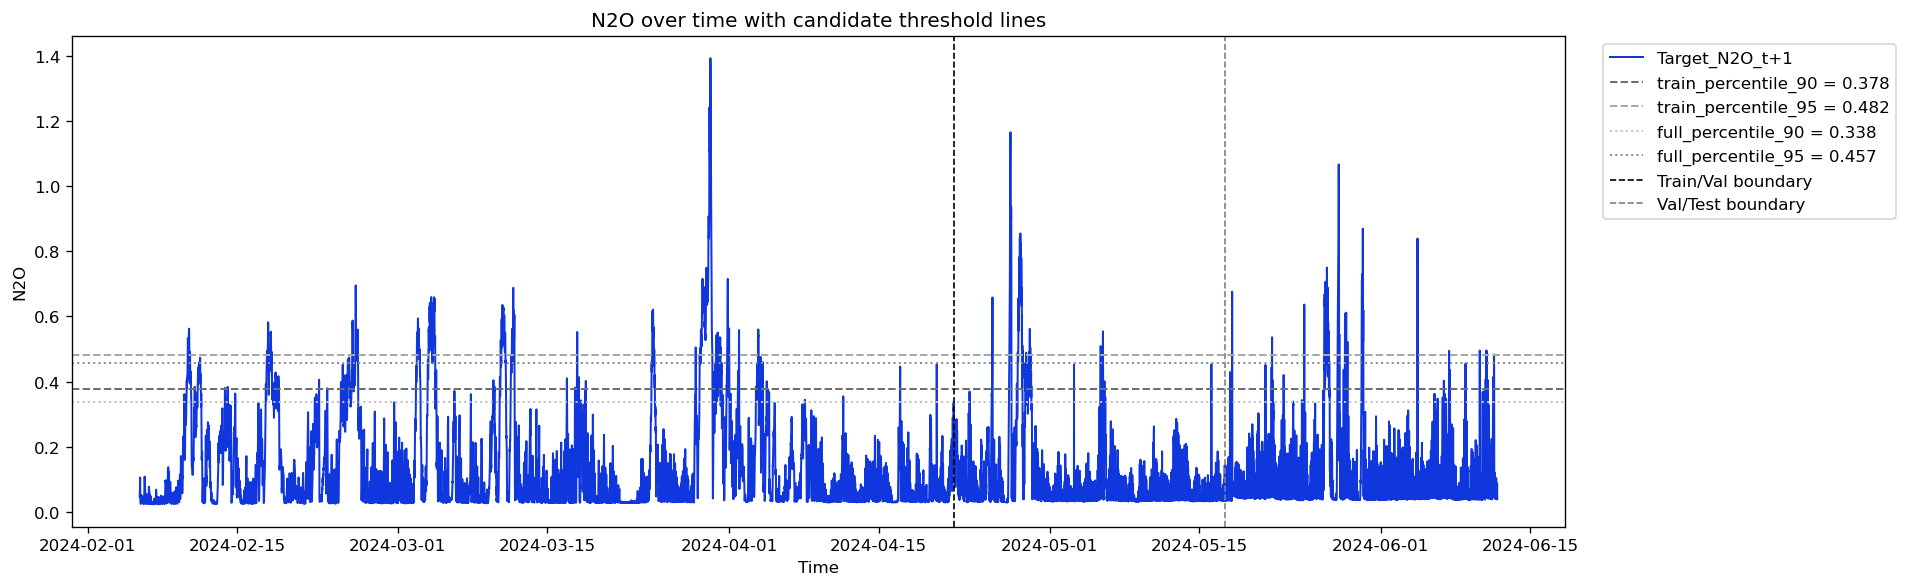

In [8]:
# ====================================================
# 7. Plot continuous target with candidate thresholds
# ====================================================

plt.figure(figsize=(16, 5))

# Main target series
plt.plot(
    df[time_col],
    df[target_col],
    linewidth=1.2,
    color=IMPERIAL_BLUE,   # or feature_color(target_col) if target_col == "t1_n2o"
    label=pretty_label(target_col)
)

# Optional neutral colours for threshold lines
threshold_colors = ["#6D6E71", "#A7A8AA", "#BFC0C2", "#8A8C8E"]

for i, (_, row) in enumerate(threshold_strategies.iterrows()):
    linestyle = "--" if row["threshold_source"] == "train_only" else ":"
    plt.axhline(
        y=row["threshold_value"],
        color=threshold_colors[i % len(threshold_colors)],
        linestyle=linestyle,
        linewidth=1.2,
        label=f"{row['strategy_name']} = {row['threshold_value']:.3f}"
    )

# Split boundaries
plt.axvline(
    train_df[time_col].max(),
    color="black",
    linestyle="--",
    linewidth=1,
    label="Train/Val boundary"
)

plt.axvline(
    val_df[time_col].max(),
    color="grey",
    linestyle="--",
    linewidth=1,
    label="Val/Test boundary"
)

plt.title("N2O over time with candidate threshold lines")
plt.xlabel("Time")
plt.ylabel("N2O")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Binary labels over time

To make drift more visible, the next section visualises the binary event labels produced by each threshold strategy. This is especially useful when later time periods have systematically higher $N_2O$ values.

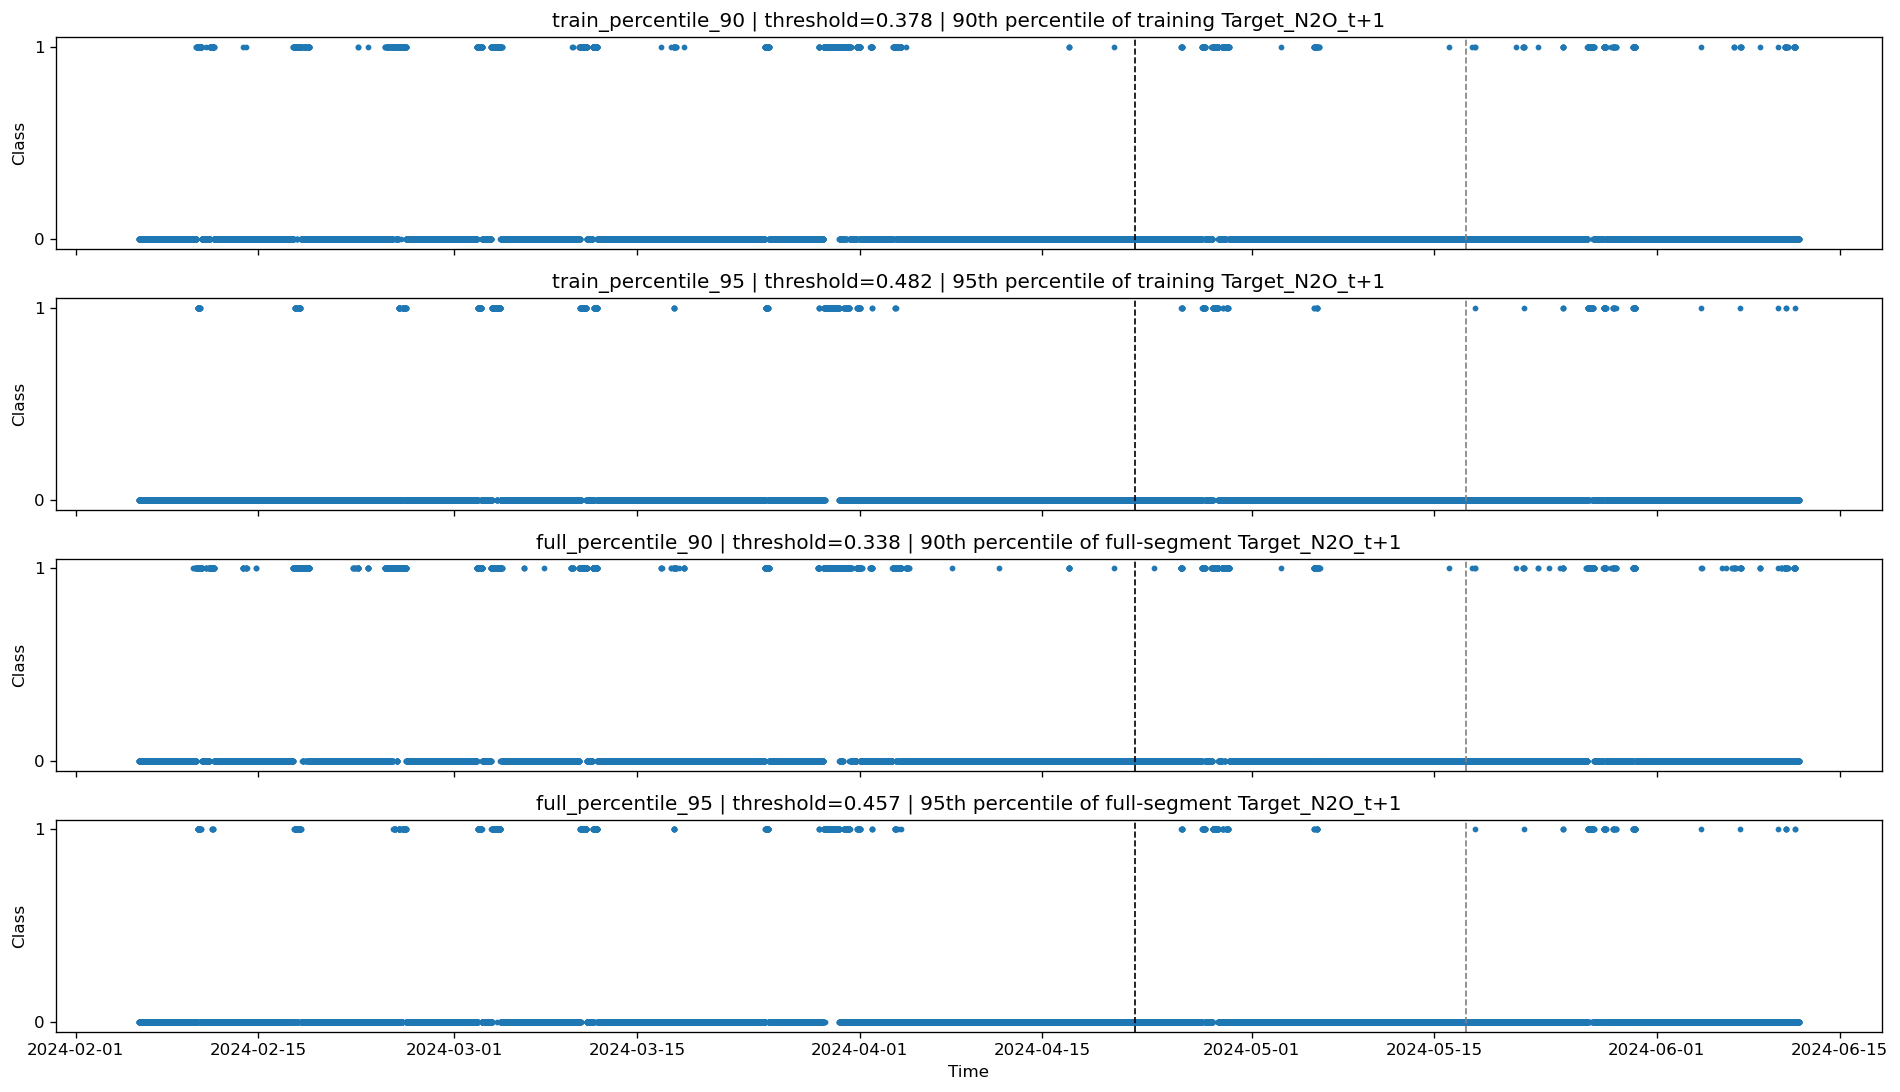

In [9]:
# ============================================
# 8. Plot binary labels over time by strategy
# ============================================

def plot_binary_labels_over_time(df, time_col, target_col, strategies_df, max_plots=None):
    rows_to_plot = strategies_df.copy()
    if max_plots is not None:
        rows_to_plot = rows_to_plot.iloc[:max_plots]

    n = len(rows_to_plot)
    fig, axes = plt.subplots(n, 1, figsize=(16, 2.3 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, rows_to_plot.iterrows()):
        y_bin = binary_label(df[target_col], row["threshold_value"])
        ax.scatter(df[time_col], y_bin, s=6)
        ax.axvline(train_df[time_col].max(), color="black", linestyle="--", linewidth=1)
        ax.axvline(val_df[time_col].max(), color="grey", linestyle="--", linewidth=1)
        ax.set_yticks([0, 1])
        ax.set_ylabel("Class")
        ax.set_title(
            f"{row['strategy_name']} | threshold={row['threshold_value']:.3f} | {row['rule_description']}"
        )

    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

plot_binary_labels_over_time(df, time_col, target_col, threshold_strategies)

## Class balance comparison by split

The next chart compares positive-class rates in train, validation, and test for each threshold strategy. Large increases in the later periods indicate temporal drift in the target distribution.

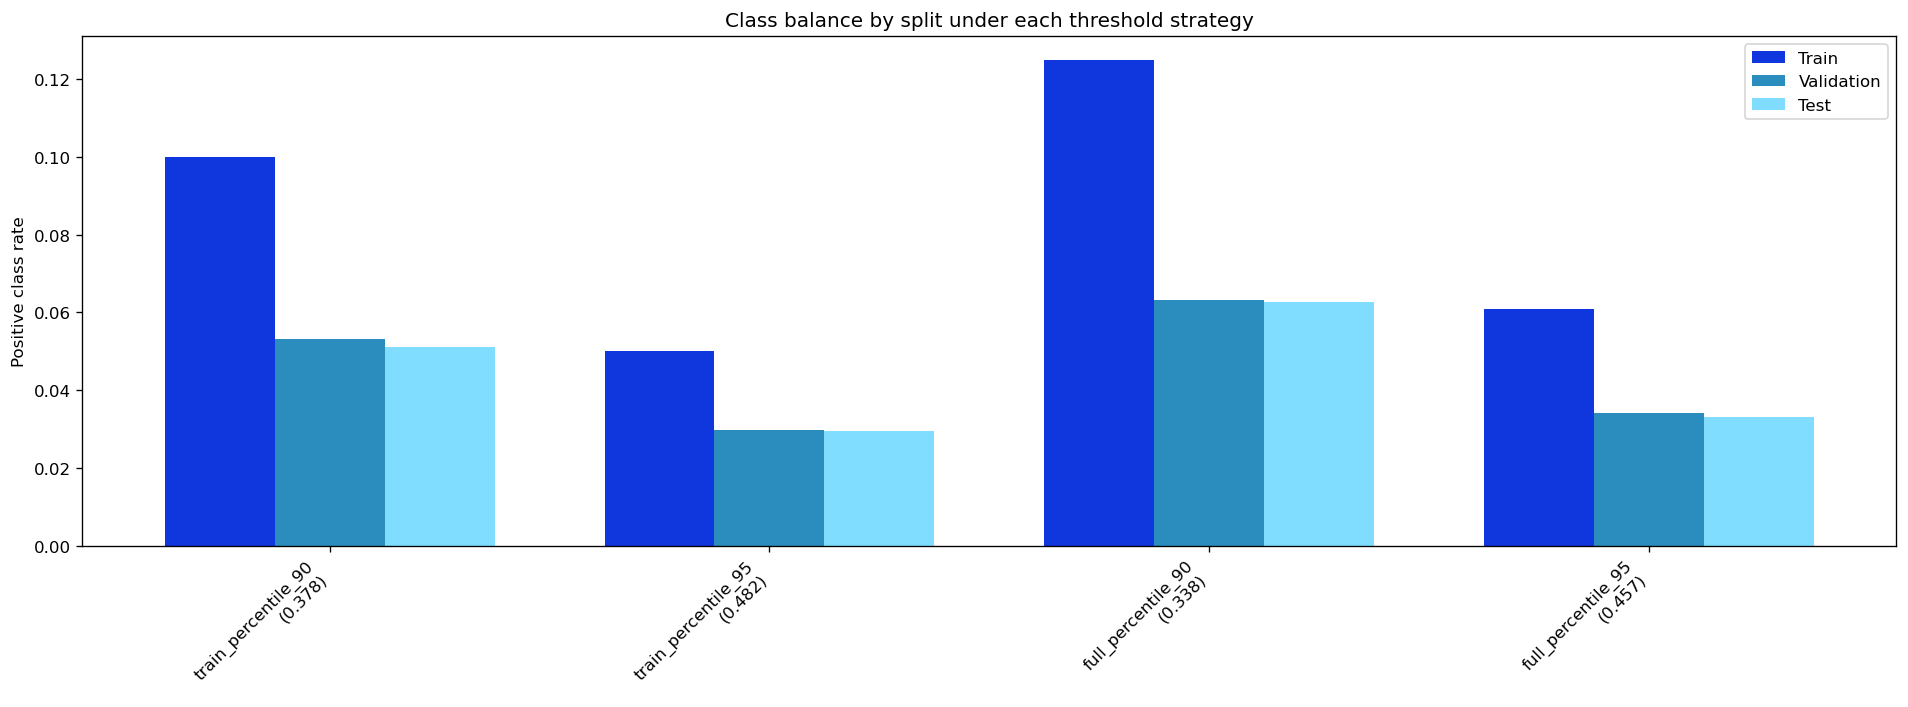

In [10]:
# ==================================
# 9. Visualise class balance by split
# ==================================

plot_df = class_balance_df.copy()
plot_df["strategy_display"] = (
    plot_df["strategy_name"] + "\n(" + plot_df["threshold_value"].round(3).astype(str) + ")"
)

strategies_order = threshold_strategies["strategy_name"].tolist()
x = np.arange(len(strategies_order))
width = 0.25

train_rates = [
    float(plot_df[(plot_df["strategy_name"] == s) & (plot_df["split"] == "train")]["positive_rate"].iloc[0])
    for s in strategies_order
]
val_rates = [
    float(plot_df[(plot_df["strategy_name"] == s) & (plot_df["split"] == "validation")]["positive_rate"].iloc[0])
    for s in strategies_order
]
test_rates = [
    float(plot_df[(plot_df["strategy_name"] == s) & (plot_df["split"] == "test")]["positive_rate"].iloc[0])
    for s in strategies_order
]

# Split colours
split_colors = {
    "Train": IMPERIAL_BLUE,
    "Validation": "#2B8CBE",
    "Test": "#80DDFF"
}

plt.figure(figsize=(16, 6))

plt.bar(
    x - width,
    train_rates,
    width=width,
    color=split_colors["Train"],
    label="Train"
)

plt.bar(
    x,
    val_rates,
    width=width,
    color=split_colors["Validation"],
    label="Validation"
)

plt.bar(
    x + width,
    test_rates,
    width=width,
    color=split_colors["Test"],
    label="Test"
)

plt.xticks(
    x,
    [
        f"{s}\n({threshold_strategies.loc[threshold_strategies['strategy_name'] == s, 'threshold_value'].iloc[0]:.3f})"
        for s in strategies_order
    ],
    rotation=45,
    ha="right"
)

plt.ylabel("Positive class rate")
plt.title("Class balance by split under each threshold strategy")
plt.legend()
plt.tight_layout()
plt.show()

## Preparing modelling inputs

Features are used exactly as supplied, with no extra feature selection.

The models use:
- all provided predictors,
- chronological train/validation/test split,
- leakage-safe preprocessing inside pipelines.

For linear models, scaling is applied inside the pipeline.  
For tree-based models, only imputation is used.

In [11]:
# ==================================
# 10. Modelling inputs and pipelines
# ==================================

X_train = train_df[feature_columns].copy()
X_val = val_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

continuous_y_train = train_df[target_col].copy()
continuous_y_val = val_df[target_col].copy()
continuous_y_test = test_df[target_col].copy()

numeric_features = feature_columns.copy()

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features)
    ],
    remainder="drop"
)

def get_model_dict(class_weight_dict, neg_pos_ratio):
    models = {
        "Logistic Regression": Pipeline([
            ("preprocessor", linear_preprocessor),
            ("model", LogisticRegression(
                max_iter=2000,
                class_weight=class_weight_dict,
                random_state=RANDOM_STATE
            ))
        ]),
        "Random Forest": Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=400,
                class_weight=class_weight_dict,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        "HistGradientBoosting": Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", HistGradientBoostingClassifier(
                random_state=RANDOM_STATE
            ))
        ]),
        "XGBoost": Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="logloss",
                scale_pos_weight=neg_pos_ratio
            ))
        ])
    }
    return models

## Optional expanding-window validation within the training portion

A single hold-out validation set is used for threshold selection and final model comparison.  
In addition, this notebook can compute an **expanding-window cross-validation summary** within the training portion to provide a more stable sense of in-training performance.

This is optional and is not used as the final test estimate.

In [12]:
# ======================================================
# 11. Optional time-series CV helper (training only)
# ======================================================

def time_series_cv_average_precision(estimator, X_train, y_train, n_splits=4):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    ap_scores = []

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        if y_tr.nunique() < 2 or y_va.nunique() < 2:
            ap_scores.append(np.nan)
            continue

        est = clone(estimator)
        est.fit(X_tr, y_tr)
        prob = est.predict_proba(X_va)[:, 1] if hasattr(est, "predict_proba") else est.decision_function(X_va)
        ap = average_precision_score(y_va, prob)
        ap_scores.append(ap)

    return {
        "cv_ap_mean": np.nanmean(ap_scores),
        "cv_ap_std": np.nanstd(ap_scores),
        "cv_ap_scores": ap_scores
    }

## Validation-based decision threshold tuning

For imbalanced classification, a probability cutoff of 0.5 is often suboptimal.  
This notebook therefore tunes the **decision threshold** on the validation set.

By default, the notebook chooses the threshold that maximises **F1 score** on the validation set, while still reporting the full set of metrics. This is a practical choice when both precision and recall matter.

You can later change this to optimise:
- recall,
- balanced accuracy,
- precision,
- or a custom cost-sensitive objective.

In [13]:
# ====================================
# 12. Evaluation helper functionality
# ====================================

def get_positive_class_probabilities(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    elif hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X)
        # Convert monotonically to [0, 1] for threshold scanning if needed
        scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores) + 1e-12)
        return scores
    else:
        raise ValueError("Estimator has neither predict_proba nor decision_function.")

def compute_metrics_from_predictions(y_true, y_prob, decision_threshold=0.3):
    y_pred = (y_prob >= decision_threshold).astype(int)

    metrics = {
        "decision_threshold": float(decision_threshold),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "pr_auc": average_precision_score(y_true, y_prob)
    }

    if len(np.unique(y_true)) == 2:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
        except Exception:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return metrics, cm, y_pred

def tune_decision_threshold(y_true, y_prob, threshold_grid=DECISION_THRESHOLD_GRID, objective="f1"):
    rows = []
    for thr in threshold_grid:
        metrics, _, _ = compute_metrics_from_predictions(y_true, y_prob, decision_threshold=thr)
        rows.append(metrics)
    df_scores = pd.DataFrame(rows)
    best_idx = df_scores[objective].idxmax()
    best_threshold = float(df_scores.loc[best_idx, "decision_threshold"])
    return best_threshold, df_scores.sort_values(objective, ascending=False).reset_index(drop=True)

def feature_importance_from_pipeline(fitted_pipeline, feature_names):
    model = fitted_pipeline.named_steps["model"]
    preprocessor = fitted_pipeline.named_steps["preprocessor"]

    try:
        transformed_feature_names = preprocessor.get_feature_names_out()
    except Exception:
        transformed_feature_names = np.array(feature_names)

    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
        return pd.DataFrame({
            "feature": transformed_feature_names,
            "importance": values
        }).sort_values("importance", ascending=False).reset_index(drop=True)

    if hasattr(model, "coef_"):
        coef = np.ravel(model.coef_)
        return pd.DataFrame({
            "feature": transformed_feature_names,
            "importance": np.abs(coef),
            "coefficient": coef
        }).sort_values("importance", ascending=False).reset_index(drop=True)

    return None

## Modelling loop across threshold strategies

For each threshold strategy, the notebook:

1. creates binary train/validation/test labels,
2. checks class balance,
3. fits each model,
4. optionally records expanding-window CV average precision inside the training block,
5. tunes the decision threshold on the validation set,
6. evaluates once on the test set.

This keeps the workflow leakage-aware:
- threshold rules based on training only are forecasting-safe;
- validation is used for probability cutoff selection;
- test is kept untouched until the end.

In [14]:
# ============================================
# 13. Main modelling loop over strategies
# ============================================

all_results = []
all_artefacts = {}

for _, strategy_row in threshold_strategies.iterrows():
    strategy_name = strategy_row["strategy_name"]
    threshold_value = float(strategy_row["threshold_value"])

    print("=" * 100)
    print(f"Running strategy: {strategy_name} | threshold = {threshold_value:.6f}")
    print(strategy_row["rule_description"])

    y_train = binary_label(continuous_y_train, threshold_value)
    y_val = binary_label(continuous_y_val, threshold_value)
    y_test = binary_label(continuous_y_test, threshold_value)
    class_weight_dict = get_class_weight_dict(y_train)
    neg_pos_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    sample_weights = get_sample_weights(y_train)

    # Skip unusable strategies if any split has only one class
    class_issue = False
    for split_name, y_split in [("train", y_train), ("validation", y_val), ("test", y_test)]:
        if y_split.nunique() < 2:
            print(f"Skipping modelling for {strategy_name}: {split_name} split has only one class.")
            class_issue = True
            break
    if class_issue:
        continue

    all_artefacts[strategy_name] = {}

    for model_name, model_pipeline in get_model_dict(class_weight_dict, neg_pos_ratio).items():
        print(f"  Fitting model: {model_name}")
        fitted = clone(model_pipeline)

        if model_name == "HistGradientBoosting":
            fitted.fit(X_train, y_train, model__sample_weight=sample_weights)
        else:
            fitted.fit(X_train, y_train)

        # Optional training-only time-series CV diagnostic
        try:
            cv_summary = time_series_cv_average_precision(
                estimator=model_pipeline,
                X_train=X_train,
                y_train=y_train,
                n_splits=N_SPLITS_INNER_CV
            )
        except Exception:
            cv_summary = {"cv_ap_mean": np.nan, "cv_ap_std": np.nan, "cv_ap_scores": []}

        # Validation threshold tuning
        val_prob = get_positive_class_probabilities(fitted, X_val)
        best_thr, val_threshold_table = tune_decision_threshold(
            y_true=y_val,
            y_prob=val_prob,
            threshold_grid=DECISION_THRESHOLD_GRID,
            objective="f1"
        )

        val_metrics, val_cm, val_pred = compute_metrics_from_predictions(y_val, val_prob, decision_threshold=best_thr)

        # Final test evaluation with validation-selected threshold
        test_prob = get_positive_class_probabilities(fitted, X_test)
        test_metrics, test_cm, test_pred = compute_metrics_from_predictions(y_test, test_prob, decision_threshold=best_thr)

        importance_df = feature_importance_from_pipeline(fitted, feature_columns)

        result_row = {
            "strategy_name": strategy_name,
            "strategy_group": strategy_row["strategy_group"],
            "rule_description": strategy_row["rule_description"],
            "threshold_source": strategy_row["threshold_source"],
            "event_threshold_value": threshold_value,
            "model": model_name,
            "train_positive_rate": float(y_train.mean()),
            "val_positive_rate": float(y_val.mean()),
            "test_positive_rate": float(y_test.mean()),
            "cv_ap_mean": cv_summary["cv_ap_mean"],
            "cv_ap_std": cv_summary["cv_ap_std"],
            "selected_decision_threshold": best_thr,
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_roc_auc": val_metrics["roc_auc"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_pr_auc": test_metrics["pr_auc"],
            "test_roc_auc": test_metrics["roc_auc"]
        }
        all_results.append(result_row)

        all_artefacts[strategy_name][model_name] = {
            "fitted_model": fitted,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
            "X_test": X_test,
            "val_prob": val_prob,
            "test_prob": test_prob,
            "val_cm": val_cm,
            "test_cm": test_cm,
            "val_threshold_table": val_threshold_table,
            "selected_decision_threshold": best_thr,
            "feature_importance": importance_df
        }

results_df = pd.DataFrame(all_results)

if results_df.empty:
    raise RuntimeError("No valid model/threshold combinations could be evaluated. Check class balance and threshold choices.")

print("Completed modelling loop.")
display(
    results_df.sort_values(
        ["val_pr_auc", "val_recall", "val_f1"],
        ascending=False
    ).head(20)
)


Running strategy: train_percentile_90 | threshold = 0.378148
90th percentile of training Target_N2O_t+1
  Fitting model: Logistic Regression
  Fitting model: Random Forest
  Fitting model: HistGradientBoosting
  Fitting model: XGBoost
Running strategy: train_percentile_95 | threshold = 0.482153
95th percentile of training Target_N2O_t+1
  Fitting model: Logistic Regression
  Fitting model: Random Forest
  Fitting model: HistGradientBoosting
  Fitting model: XGBoost
Running strategy: full_percentile_90 | threshold = 0.337616
90th percentile of full-segment Target_N2O_t+1
  Fitting model: Logistic Regression
  Fitting model: Random Forest
  Fitting model: HistGradientBoosting
  Fitting model: XGBoost
Running strategy: full_percentile_95 | threshold = 0.456597
95th percentile of full-segment Target_N2O_t+1
  Fitting model: Logistic Regression
  Fitting model: Random Forest
  Fitting model: HistGradientBoosting
  Fitting model: XGBoost
Completed modelling loop.


,strategy_name,strategy_group,rule_description,threshold_source,event_threshold_value,model,train_positive_rate,val_positive_rate,test_positive_rate,cv_ap_mean,...,val_f1,val_balanced_accuracy,val_pr_auc,val_roc_auc,test_precision,test_recall,test_f1,test_balanced_accuracy,test_pr_auc,test_roc_auc
10,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,full_segment,0.337616,HistGradientBoosting,0.124761,0.063201,0.062637,0.286431,...,0.317241,0.597669,0.374147,0.753294,0.785714,0.048035,0.090535,0.523580,0.257915,0.722216
6,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,train_only,0.482153,HistGradientBoosting,0.050068,0.029822,0.029540,0.328821,...,0.296875,0.587156,0.360989,0.763479,0.000000,0.000000,0.000000,0.500000,0.121566,0.688160
2,train_percentile_90,train_percentile,90th percentile of training Target_N2O_t+1,train_only,0.378148,HistGradientBoosting,0.100046,0.053078,0.051149,0.241811,...,0.257778,0.574453,0.356445,0.760995,1.000000,0.005348,0.010638,0.502674,0.230377,0.713383
9,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,full_segment,0.337616,Random Forest,0.124761,0.063201,0.062637,0.254561,...,0.363636,0.636234,0.337638,0.647082,0.517647,0.192140,0.280255,0.590088,0.241749,0.642964
11,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,full_segment,0.337616,XGBoost,0.124761,0.063201,0.062637,0.299515,...,0.209302,0.558442,0.332052,0.631308,0.500000,0.013100,0.025532,0.506113,0.197663,0.630976
15,full_percentile_95,full_percentile_sensitivity,95th percentile of full-segment Target_N2O_t+1,full_segment,0.456597,XGBoost,0.060830,0.034200,0.033096,0.356153,...,0.161765,0.544000,0.328660,0.668666,0.000000,0.000000,0.000000,0.500000,0.119786,0.681356
14,full_percentile_95,full_percentile_sensitivity,95th percentile of full-segment Target_N2O_t+1,full_segment,0.456597,HistGradientBoosting,0.060830,0.034200,0.033096,0.333300,...,0.291391,0.587433,0.314598,0.762926,0.000000,0.000000,0.000000,0.500000,0.192425,0.697802
7,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,train_only,0.482153,XGBoost,0.050068,0.029822,0.029540,0.336682,...,0.269841,0.577982,0.313772,0.578644,0.000000,0.000000,0.000000,0.500000,0.113170,0.658509
1,train_percentile_90,train_percentile,90th percentile of training Target_N2O_t+1,train_only,0.378148,Random Forest,0.100046,0.053078,0.051149,0.237155,...,0.359322,0.629664,0.297302,0.622107,0.613636,0.144385,0.233766,0.569742,0.187685,0.600261
5,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,train_only,0.482153,Random Forest,0.050068,0.029822,0.029540,0.306990,...,0.360000,0.621879,0.290438,0.654663,0.600000,0.111111,0.187500,0.554428,0.205536,0.692472


## Ranked model comparison

The next table ranks strategy-model combinations.  
For imbalanced classification, **PR-AUC** and **F1** are often more informative than raw accuracy, so the table is sorted primarily by validation PR-AUC.


In [15]:
# ===========================
# 14. Ranked model comparison
# ===========================

ranked_results = results_df.sort_values(
    by=["val_pr_auc", "val_recall", "val_f1"],
    ascending=False
).reset_index(drop=True)

display(ranked_results)

best_row = ranked_results.iloc[0]
print("Best combination by ranking:")
display(best_row.to_frame(name="value"))

,strategy_name,strategy_group,rule_description,threshold_source,event_threshold_value,model,train_positive_rate,val_positive_rate,test_positive_rate,cv_ap_mean,...,val_f1,val_balanced_accuracy,val_pr_auc,val_roc_auc,test_precision,test_recall,test_f1,test_balanced_accuracy,test_pr_auc,test_roc_auc
0,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,full_segment,0.337616,HistGradientBoosting,0.124761,0.063201,0.062637,0.286431,...,0.317241,0.597669,0.374147,0.753294,0.785714,0.048035,0.090535,0.523580,0.257915,0.722216
1,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,train_only,0.482153,HistGradientBoosting,0.050068,0.029822,0.029540,0.328821,...,0.296875,0.587156,0.360989,0.763479,0.000000,0.000000,0.000000,0.500000,0.121566,0.688160
2,train_percentile_90,train_percentile,90th percentile of training Target_N2O_t+1,train_only,0.378148,HistGradientBoosting,0.100046,0.053078,0.051149,0.241811,...,0.257778,0.574453,0.356445,0.760995,1.000000,0.005348,0.010638,0.502674,0.230377,0.713383
3,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,full_segment,0.337616,Random Forest,0.124761,0.063201,0.062637,0.254561,...,0.363636,0.636234,0.337638,0.647082,0.517647,0.192140,0.280255,0.590088,0.241749,0.642964
4,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,full_segment,0.337616,XGBoost,0.124761,0.063201,0.062637,0.299515,...,0.209302,0.558442,0.332052,0.631308,0.500000,0.013100,0.025532,0.506113,0.197663,0.630976
5,full_percentile_95,full_percentile_sensitivity,95th percentile of full-segment Target_N2O_t+1,full_segment,0.456597,XGBoost,0.060830,0.034200,0.033096,0.356153,...,0.161765,0.544000,0.328660,0.668666,0.000000,0.000000,0.000000,0.500000,0.119786,0.681356
6,full_percentile_95,full_percentile_sensitivity,95th percentile of full-segment Target_N2O_t+1,full_segment,0.456597,HistGradientBoosting,0.060830,0.034200,0.033096,0.333300,...,0.291391,0.587433,0.314598,0.762926,0.000000,0.000000,0.000000,0.500000,0.192425,0.697802
7,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,train_only,0.482153,XGBoost,0.050068,0.029822,0.029540,0.336682,...,0.269841,0.577982,0.313772,0.578644,0.000000,0.000000,0.000000,0.500000,0.113170,0.658509
8,train_percentile_90,train_percentile,90th percentile of training Target_N2O_t+1,train_only,0.378148,Random Forest,0.100046,0.053078,0.051149,0.237155,...,0.359322,0.629664,0.297302,0.622107,0.613636,0.144385,0.233766,0.569742,0.187685,0.600261
9,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,train_only,0.482153,Random Forest,0.050068,0.029822,0.029540,0.306990,...,0.360000,0.621879,0.290438,0.654663,0.600000,0.111111,0.187500,0.554428,0.205536,0.692472


Best combination by ranking:


,value
strategy_name,full_percentile_90
strategy_group,full_percentile_sensitivity
rule_description,90th percentile of full-segment Target_N2O_t+1
threshold_source,full_segment
event_threshold_value,0.337616
model,HistGradientBoosting
train_positive_rate,0.124761
val_positive_rate,0.063201
test_positive_rate,0.062637
cv_ap_mean,0.286431


## Inspecting threshold-tuning behaviour

This helps check whether the selected probability cutoff is materially different from 0.5 and whether performance is very sensitive to the cutoff choice.

Best strategy: full_percentile_90
Best model: HistGradientBoosting
Selected decision threshold: 0.05


,decision_threshold,precision,recall,f1,balanced_accuracy,pr_auc,roc_auc
0,0.05,0.779661,0.199134,0.317241,0.597669,0.374147,0.753294
1,0.10,0.883721,0.164502,0.277372,0.581521,0.374147,0.753294
2,0.15,0.968750,0.134199,0.235741,0.566954,0.374147,0.753294
3,0.20,0.965517,0.121212,0.215385,0.560460,0.374147,0.753294
4,0.25,0.962963,0.112554,0.201550,0.556131,0.374147,0.753294
5,0.30,1.000000,0.099567,0.181102,0.549784,0.374147,0.753294
6,0.35,1.000000,0.086580,0.159363,0.543290,0.374147,0.753294
7,0.40,1.000000,0.077922,0.144578,0.538961,0.374147,0.753294
8,0.45,1.000000,0.073593,0.137097,0.536797,0.374147,0.753294
9,0.50,1.000000,0.069264,0.129555,0.534632,0.374147,0.753294


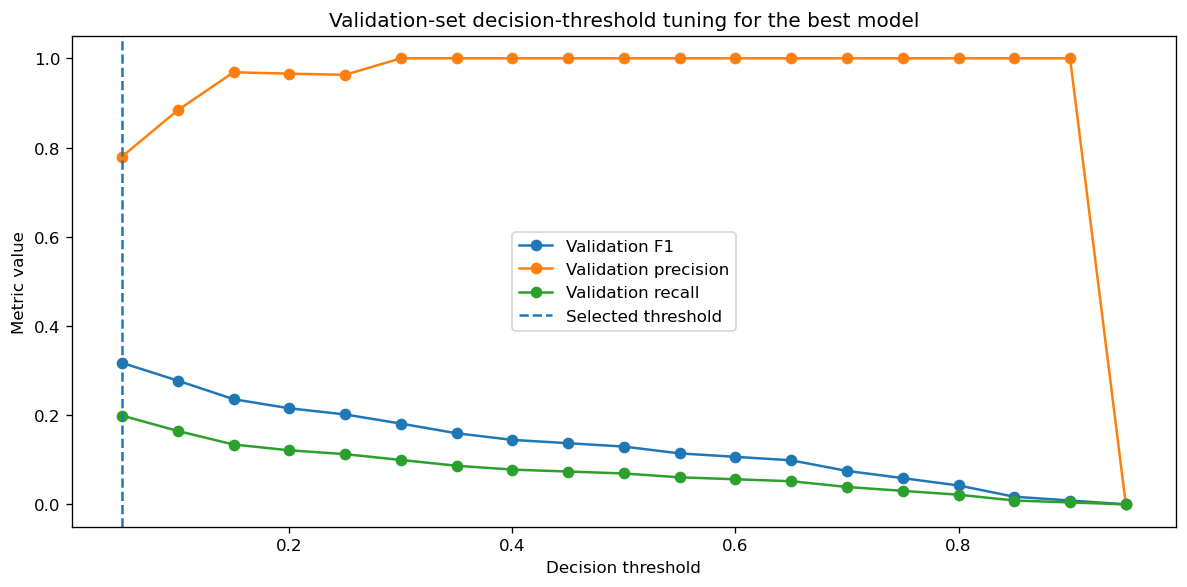

In [16]:
# =======================================
# 15. Validation threshold-tuning display
# =======================================

best_strategy_name = best_row["strategy_name"]
best_model_name = best_row["model"]

best_artefact = all_artefacts[best_strategy_name][best_model_name]
best_threshold_table = best_artefact["val_threshold_table"]

print(f"Best strategy: {best_strategy_name}")
print(f"Best model: {best_model_name}")
print(f"Selected decision threshold: {best_artefact['selected_decision_threshold']:.2f}")

display(best_threshold_table.head(15))

plt.figure(figsize=(10, 5))
plt.plot(best_threshold_table["decision_threshold"], best_threshold_table["f1"], marker="o", label="Validation F1")
plt.plot(best_threshold_table["decision_threshold"], best_threshold_table["precision"], marker="o", label="Validation precision")
plt.plot(best_threshold_table["decision_threshold"], best_threshold_table["recall"], marker="o", label="Validation recall")
plt.axvline(best_artefact["selected_decision_threshold"], linestyle="--", linewidth=1.5, label="Selected threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.title("Validation-set decision-threshold tuning for the best model")
plt.legend()
plt.tight_layout()
plt.show()

## Confusion matrices

The following plots show confusion matrices for the best configuration on both validation and test.

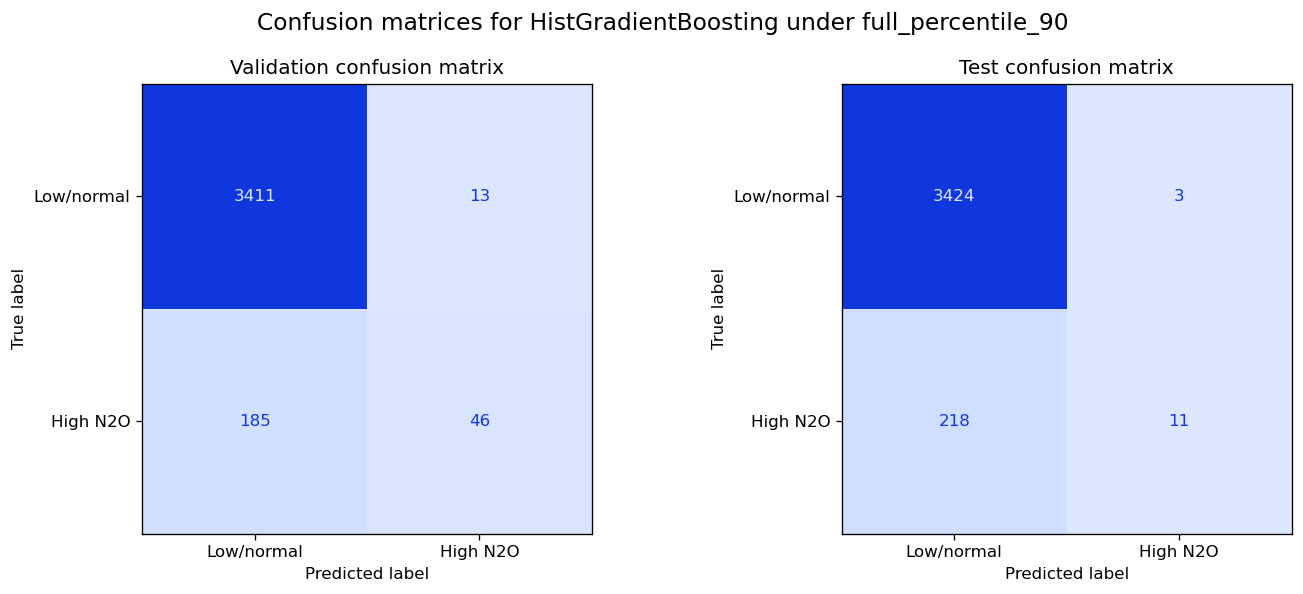

In [17]:
# =======================
# 16. Confusion matrices
# =======================
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

imperial_seq_blue = LinearSegmentedColormap.from_list(
    "imperial_seq_blue",
    ["#DCE6FF", "#7FA8FF", "#1036DD"]
)

# Shared colour scale across both matrices
all_cm_values = np.concatenate([
    best_artefact["val_cm"].ravel(),
    best_artefact["test_cm"].ravel()
])
norm = mcolors.Normalize(vmin=all_cm_values.min(), vmax=all_cm_values.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=best_artefact["val_cm"],
    display_labels=["Low/normal", "High N2O"]
).plot(
    ax=axes[0],
    values_format="d",
    colorbar=False,
    cmap=imperial_seq_blue,
    im_kw={"norm": norm}
)
axes[0].set_title("Validation confusion matrix")
axes[0].tick_params(axis="both", labelsize=10)

ConfusionMatrixDisplay(
    confusion_matrix=best_artefact["test_cm"],
    display_labels=["Low/normal", "High N2O"]
).plot(
    ax=axes[1],
    values_format="d",
    colorbar=False,
    cmap=imperial_seq_blue,
    im_kw={"norm": norm}
)
axes[1].set_title("Test confusion matrix")
axes[1].tick_params(axis="both", labelsize=10)
fig.suptitle(f"Confusion matrices for {best_model_name} under {best_strategy_name}", fontsize=14)
plt.tight_layout()
plt.show()

## Precision-recall and ROC curves

Precision-recall curves are especially useful here because high-N$_2$O events may be rare, and performance on the positive class matters most.

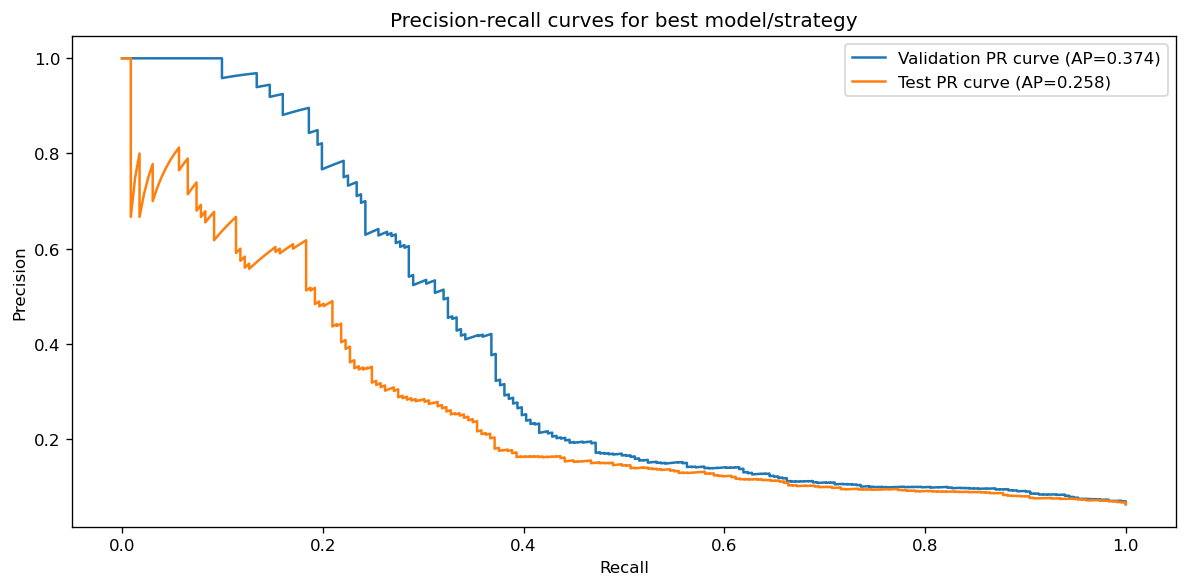

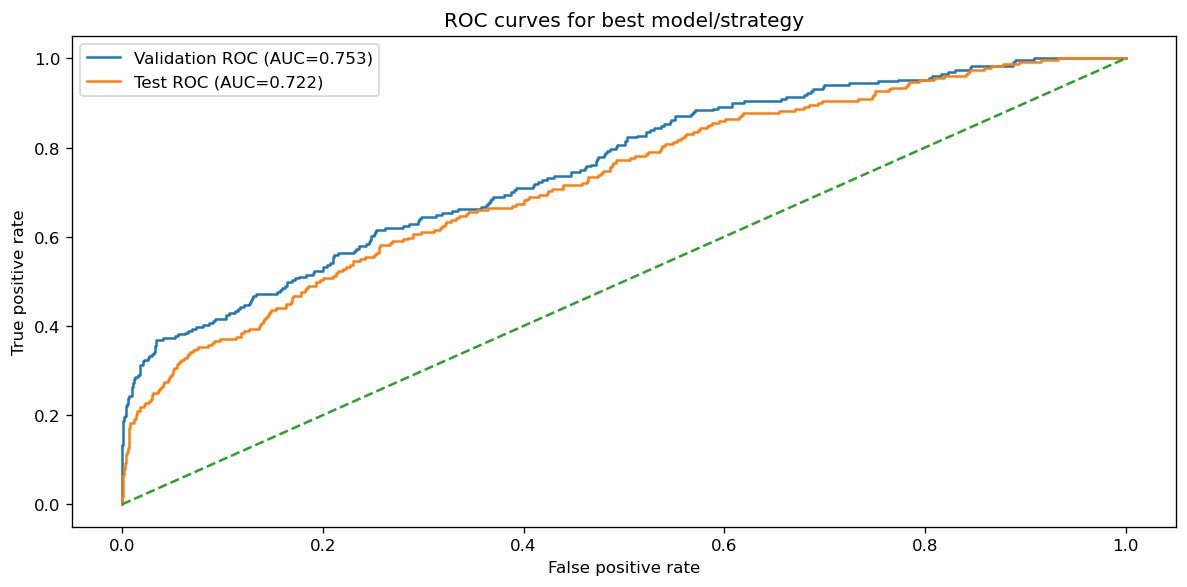

In [18]:
# ===============================
# 17. PR and ROC curves for best
# ===============================

y_val_best = best_artefact["y_val"]
y_test_best = best_artefact["y_test"]
val_prob_best = best_artefact["val_prob"]
test_prob_best = best_artefact["test_prob"]

val_precision_curve, val_recall_curve, _ = precision_recall_curve(y_val_best, val_prob_best)
test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test_best, test_prob_best)

plt.figure(figsize=(10, 5))
plt.plot(val_recall_curve, val_precision_curve, label=f"Validation PR curve (AP={average_precision_score(y_val_best, val_prob_best):.3f})")
plt.plot(test_recall_curve, test_precision_curve, label=f"Test PR curve (AP={average_precision_score(y_test_best, test_prob_best):.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves for best model/strategy")
plt.legend()
plt.tight_layout()
plt.show()

if len(np.unique(y_val_best)) == 2 and len(np.unique(y_test_best)) == 2:
    val_fpr, val_tpr, _ = roc_curve(y_val_best, val_prob_best)
    test_fpr, test_tpr, _ = roc_curve(y_test_best, test_prob_best)

    plt.figure(figsize=(10, 5))
    plt.plot(val_fpr, val_tpr, label=f"Validation ROC (AUC={roc_auc_score(y_val_best, val_prob_best):.3f})")
    plt.plot(test_fpr, test_tpr, label=f"Test ROC (AUC={roc_auc_score(y_test_best, test_prob_best):.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC curves for best model/strategy")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Feature importance for the best model

Where supported, the notebook extracts model-based feature importance or absolute coefficient magnitude.

Interpret these carefully:
- logistic regression coefficients are scale-dependent before standardisation, but here scaling occurs inside the pipeline;
- tree-based importances indicate relative split utility, not causal importance.

,strategy_name,model,event_threshold_value,selected_decision_threshold,val_pr_auc,val_f1,val_balanced_accuracy,test_f1,test_pr_auc,test_balanced_accuracy,test_precision,test_recall
0,full_percentile_90,HistGradientBoosting,0.337616,0.05,0.374147,0.317241,0.597669,0.090535,0.257915,0.523580,0.785714,0.048035
1,full_percentile_95,XGBoost,0.456597,0.05,0.328660,0.161765,0.544000,0.000000,0.119786,0.500000,0.000000,0.000000
2,train_percentile_90,HistGradientBoosting,0.378148,0.05,0.356445,0.257778,0.574453,0.010638,0.230377,0.502674,1.000000,0.005348
3,train_percentile_95,HistGradientBoosting,0.482153,0.05,0.360989,0.296875,0.587156,0.000000,0.121566,0.500000,0.000000,0.000000


Threshold strategy: full_percentile_90
Best model: HistGradientBoosting
Built-in feature importance not available; using permutation importance on the test set.


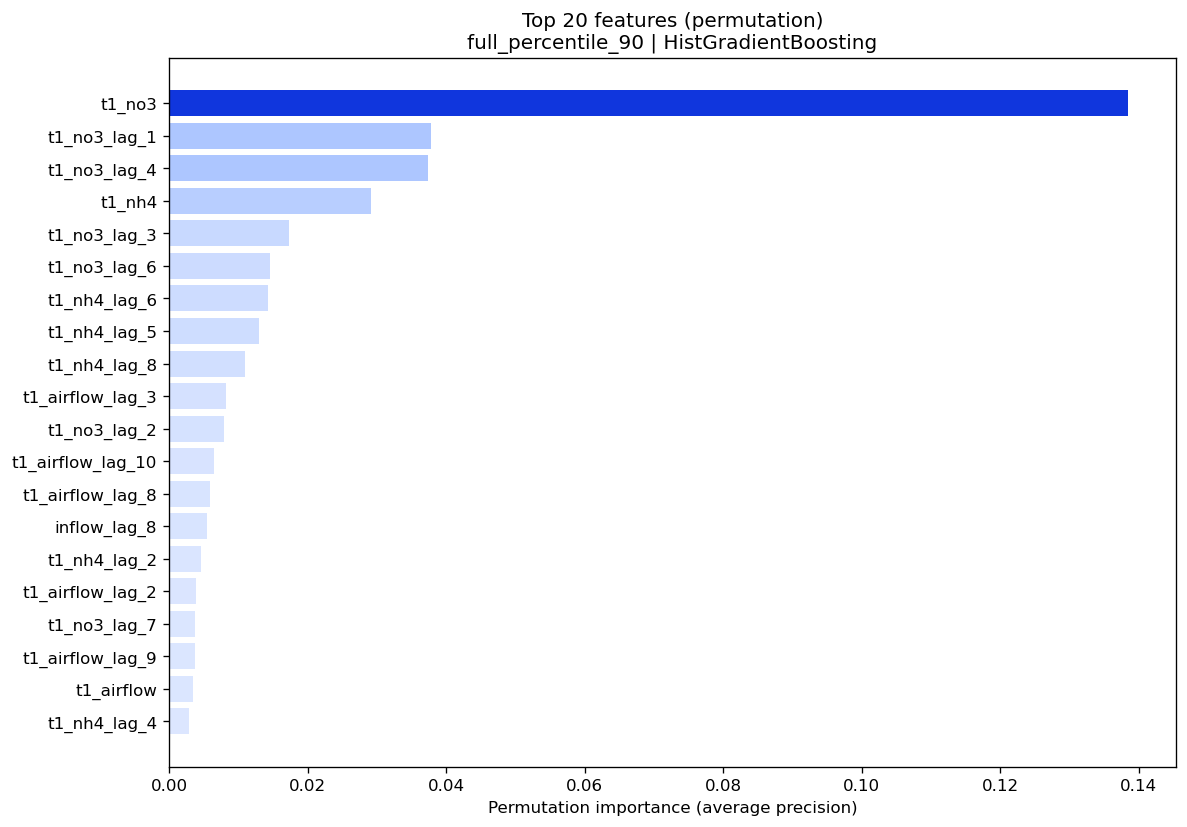

,feature,importance,importance_std
0,t1_no3,0.138435,0.006722
1,t1_no3_lag_1,0.037792,0.004049
2,t1_no3_lag_4,0.037321,0.004522
3,t1_nh4,0.029088,0.010701
4,t1_no3_lag_3,0.017255,0.002313
5,t1_no3_lag_6,0.014544,0.004327
6,t1_nh4_lag_6,0.014316,0.002988
7,t1_nh4_lag_5,0.012998,0.002544
8,t1_nh4_lag_8,0.010967,0.001672
9,t1_airflow_lag_3,0.008168,0.003449


Threshold strategy: full_percentile_95
Best model: XGBoost


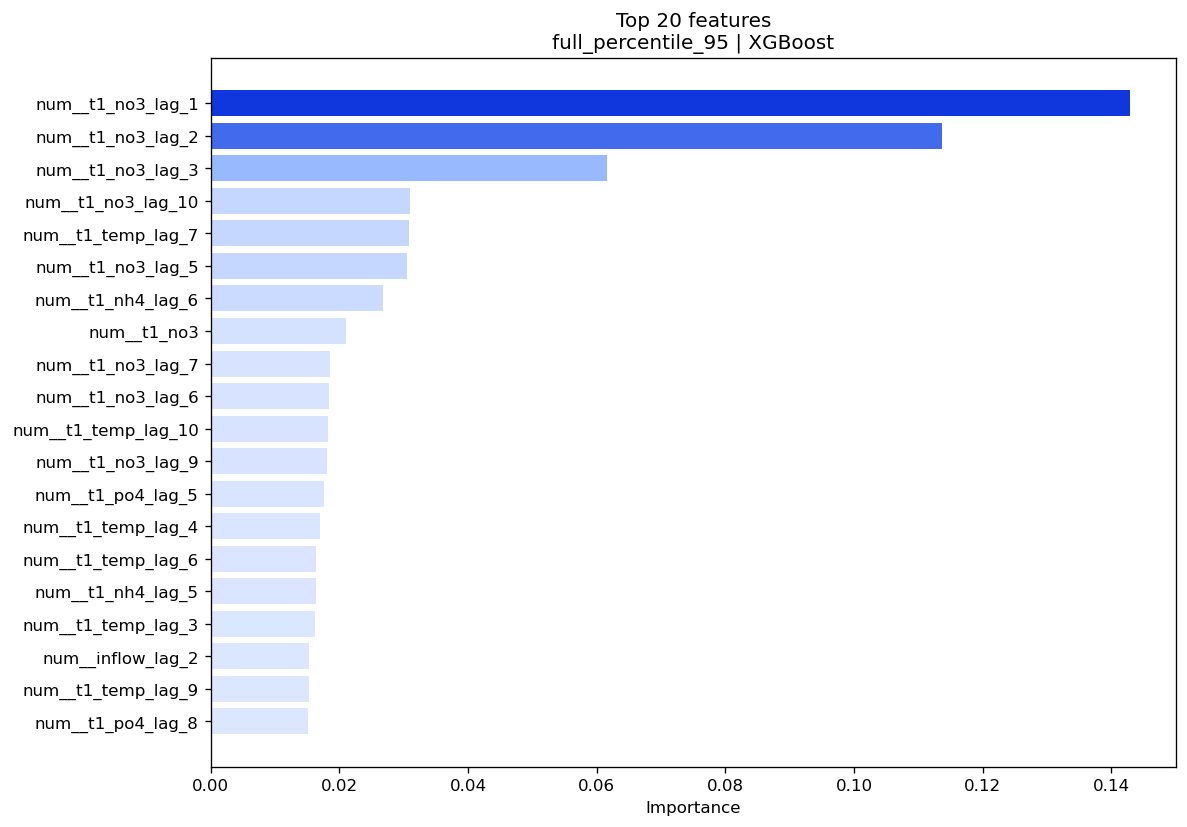

,feature,importance
0,num__t1_no3_lag_1,0.142885
1,num__t1_no3_lag_2,0.113736
2,num__t1_no3_lag_3,0.061555
3,num__t1_no3_lag_10,0.030930
4,num__t1_temp_lag_7,0.030875
5,num__t1_no3_lag_5,0.030601
6,num__t1_nh4_lag_6,0.026762
7,num__t1_no3,0.021059
8,num__t1_no3_lag_7,0.018637
9,num__t1_no3_lag_6,0.018330


Threshold strategy: train_percentile_90
Best model: HistGradientBoosting
Built-in feature importance not available; using permutation importance on the test set.


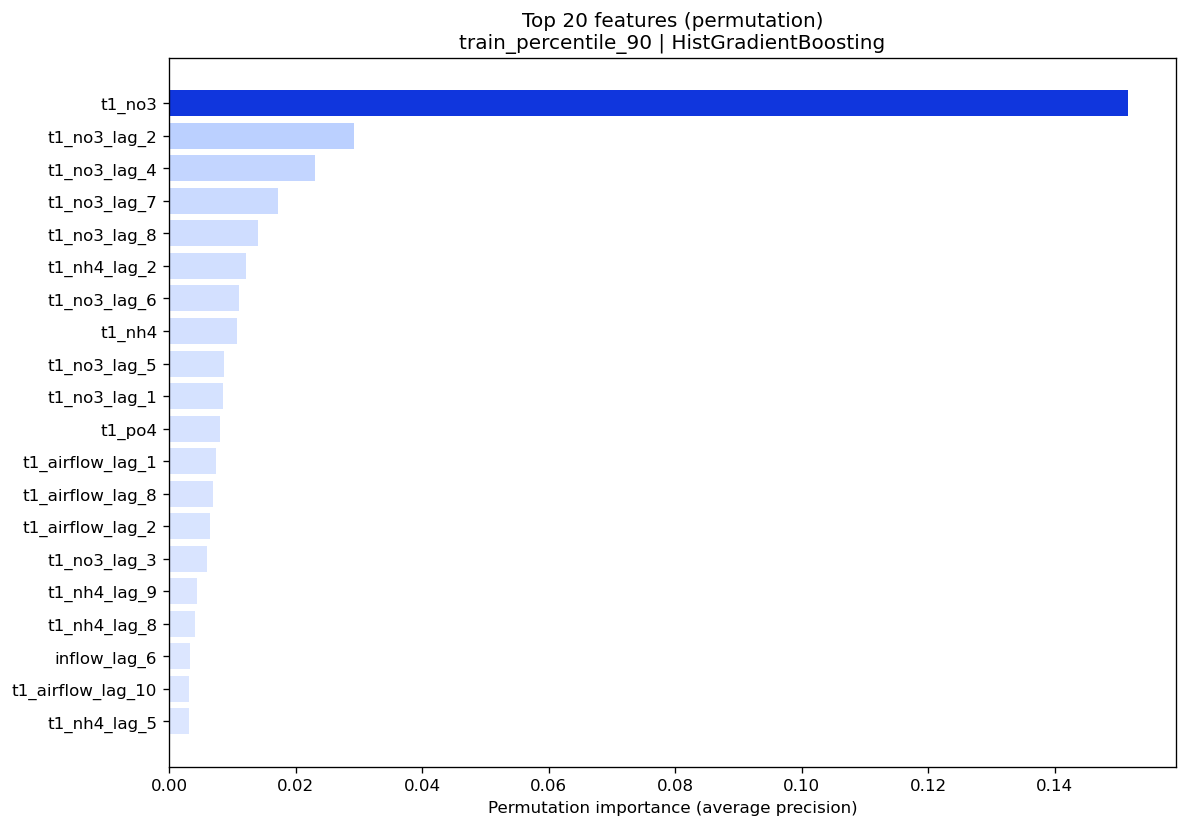

,feature,importance,importance_std
0,t1_no3,0.151559,0.007228
1,t1_no3_lag_2,0.029285,0.003285
2,t1_no3_lag_4,0.023119,0.005562
3,t1_no3_lag_7,0.017246,0.003203
4,t1_no3_lag_8,0.014036,0.002851
5,t1_nh4_lag_2,0.012177,0.003359
6,t1_no3_lag_6,0.010989,0.006071
7,t1_nh4,0.010751,0.004880
8,t1_no3_lag_5,0.008738,0.003099
9,t1_no3_lag_1,0.008531,0.003021


Threshold strategy: train_percentile_95
Best model: HistGradientBoosting
Built-in feature importance not available; using permutation importance on the test set.


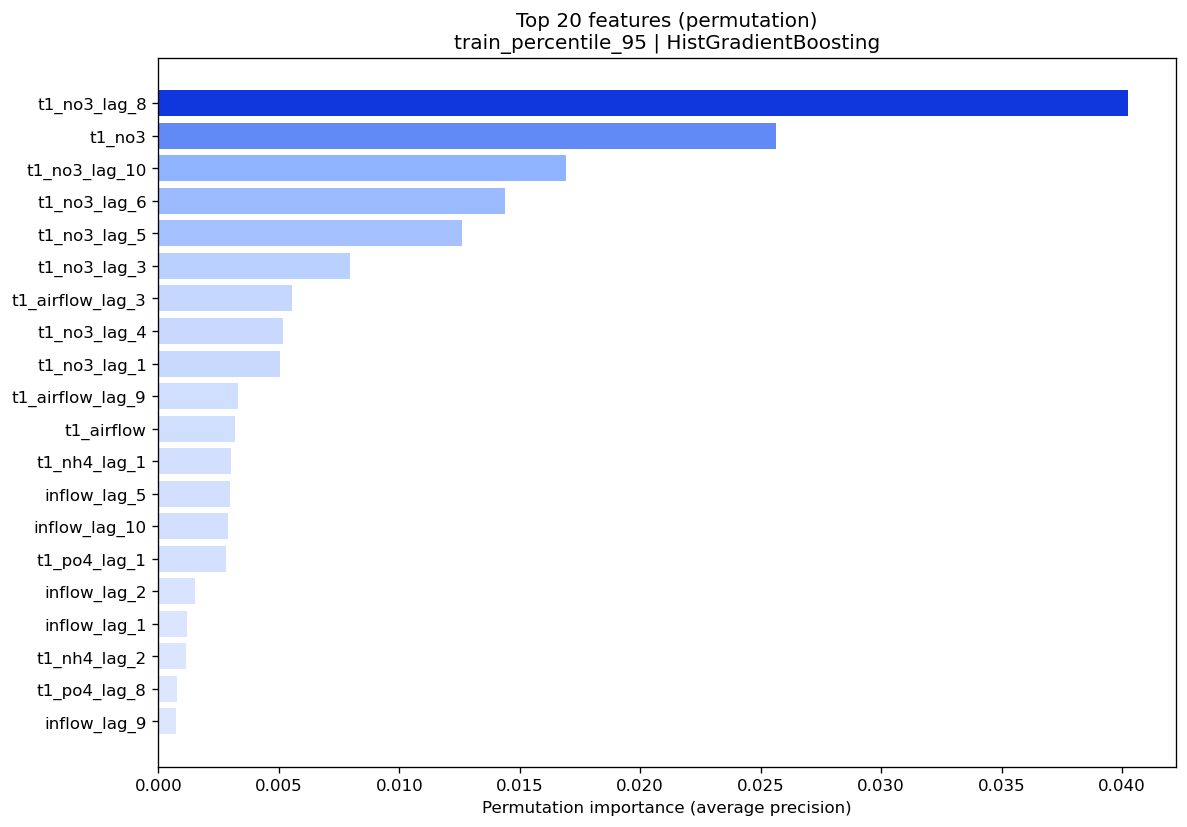

,feature,importance,importance_std
0,t1_no3_lag_8,0.040231,0.010529
1,t1_no3,0.025648,0.005076
2,t1_no3_lag_10,0.016922,0.005295
3,t1_no3_lag_6,0.014371,0.003850
4,t1_no3_lag_5,0.012600,0.001514
5,t1_no3_lag_3,0.007969,0.001495
6,t1_airflow_lag_3,0.005545,0.001268
7,t1_no3_lag_4,0.005187,0.001898
8,t1_no3_lag_1,0.005031,0.006337
9,t1_airflow_lag_9,0.003290,0.001840


In [19]:
# ============================
# 18. Feature importance plot
# ============================

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

imperial_seq_blue = LinearSegmentedColormap.from_list(
    "imperial_seq_blue",
    ["#DCE6FF", "#7FA8FF", "#1036DD"]
)

best_per_threshold = (
    results_df.loc[results_df.groupby("strategy_name")["val_pr_auc"].idxmax(), [
        "strategy_name",
        "model",
        "event_threshold_value",
        "selected_decision_threshold",
        "val_pr_auc",
        "val_f1",
        "val_balanced_accuracy",
        "test_f1",
        "test_pr_auc",
        "test_balanced_accuracy",
        "test_precision",
        "test_recall"
    ]]
    .sort_values("strategy_name")
    .reset_index(drop=True)
)

display(best_per_threshold)

for _, row in best_per_threshold.iterrows():
    strategy_name = row["strategy_name"]
    model_name = row["model"]

    print("=" * 100)
    print(f"Threshold strategy: {strategy_name}")
    print(f"Best model: {model_name}")

    artefact = all_artefacts[strategy_name][model_name]
    fitted_model = artefact["fitted_model"]
    importance_df = artefact["feature_importance"]

    # Case 1: built-in importance/coefficient is available
    if importance_df is not None and not importance_df.empty:
        top_k = min(20, len(importance_df))
        top_imp = importance_df.head(top_k).iloc[::-1].copy()

        norm = mcolors.Normalize(
            vmin=top_imp["importance"].min(),
            vmax=top_imp["importance"].max()
        )
        bar_colors = imperial_seq_blue(norm(top_imp["importance"].values))

        plt.figure(figsize=(10, 7))
        plt.barh(
            top_imp["feature"],
            top_imp["importance"],
            color=bar_colors
        )
        plt.xlabel("Importance")
        plt.title(f"Top {top_k} features\n{strategy_name} | {model_name}")
        plt.tight_layout()
        plt.show()

        display(importance_df.head(40))

    # Case 2: fall back to permutation importance
    else:
        print("Built-in feature importance not available; using permutation importance on the test set.")

        X_test_local = artefact["X_test"]
        y_test_local = artefact["y_test"]

        perm_result = permutation_importance(
            fitted_model,
            X_test_local,
            y_test_local,
            n_repeats=10,
            random_state=RANDOM_STATE,
            scoring="average_precision"
        )

        feature_names = X_test_local.columns if hasattr(X_test_local, "columns") else feature_columns

        perm_importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": perm_result.importances_mean,
            "importance_std": perm_result.importances_std
        }).sort_values("importance", ascending=False).reset_index(drop=True)

        top_k = min(20, len(perm_importance_df))
        top_imp = perm_importance_df.head(top_k).iloc[::-1].copy()

        norm = mcolors.Normalize(
            vmin=top_imp["importance"].min(),
            vmax=top_imp["importance"].max()
        )
        bar_colors = imperial_seq_blue(norm(top_imp["importance"].values))

        plt.figure(figsize=(10, 7))
        plt.barh(
            top_imp["feature"],
            top_imp["importance"],
            color=bar_colors
        )
        plt.xlabel("Permutation importance (average precision)")
        plt.title(f"Top {top_k} features (permutation)\n{strategy_name} | {model_name}")
        plt.tight_layout()
        plt.show()

        display(perm_importance_df.head(40))


## Temporal drift diagnostics

The next small summary focuses on class-rate drift between train, validation, and test.  
This is central in this problem, because some threshold rules may produce much more severe event prevalence later in the segment.

In [20]:
# ===========================
# 19. Temporal drift summary
# ===========================

drift_summary = ranked_results[[
    "strategy_name", "model", "train_positive_rate", "val_positive_rate", "test_positive_rate",
    "test_pr_auc", "test_f1", "test_balanced_accuracy"
]].copy()

drift_summary["val_minus_train"] = drift_summary["val_positive_rate"] - drift_summary["train_positive_rate"]
drift_summary["test_minus_train"] = drift_summary["test_positive_rate"] - drift_summary["train_positive_rate"]

display(drift_summary.sort_values("test_minus_train", ascending=False).head(20))

,strategy_name,model,train_positive_rate,val_positive_rate,test_positive_rate,test_pr_auc,test_f1,test_balanced_accuracy,val_minus_train,test_minus_train
1,train_percentile_95,HistGradientBoosting,0.050068,0.029822,0.029540,0.121566,0.000000,0.500000,-0.020246,-0.020528
7,train_percentile_95,XGBoost,0.050068,0.029822,0.029540,0.113170,0.000000,0.500000,-0.020246,-0.020528
15,train_percentile_95,Logistic Regression,0.050068,0.029822,0.029540,0.036295,0.000000,0.500000,-0.020246,-0.020528
9,train_percentile_95,Random Forest,0.050068,0.029822,0.029540,0.205536,0.187500,0.554428,-0.020246,-0.020528
10,full_percentile_95,Random Forest,0.060830,0.034200,0.033096,0.207716,0.200000,0.560003,-0.026630,-0.027734
14,full_percentile_95,Logistic Regression,0.060830,0.034200,0.033096,0.039808,0.000000,0.500000,-0.026630,-0.027734
5,full_percentile_95,XGBoost,0.060830,0.034200,0.033096,0.119786,0.000000,0.500000,-0.026630,-0.027734
6,full_percentile_95,HistGradientBoosting,0.060830,0.034200,0.033096,0.192425,0.000000,0.500000,-0.026630,-0.027734
11,train_percentile_90,XGBoost,0.100046,0.053078,0.051149,0.153552,0.010638,0.502674,-0.046968,-0.048897
8,train_percentile_90,Random Forest,0.100046,0.053078,0.051149,0.187685,0.233766,0.569742,-0.046968,-0.048897


## Compact helper views

The following cells provide compact summaries by threshold strategy and by model family. These are useful when adapting the notebook to other segments.

In [21]:
# =====================================
# 20. Aggregated summaries for reuse
# =====================================

summary_by_strategy = (
    results_df.groupby(["strategy_name", "strategy_group", "rule_description", "event_threshold_value"], as_index=False)
    .agg(
        mean_val_pr_auc=("val_pr_auc", "mean"),
        max_val_pr_auc=("val_pr_auc", "max"),
        mean_val_f1=("val_f1", "mean"),
        max_val_f1=("val_f1", "max"),
        mean_val_balanced_accuracy=("val_balanced_accuracy", "mean"),
        mean_test_pr_auc=("test_pr_auc", "mean"),
        mean_test_f1=("test_f1", "mean"),
        mean_test_balanced_accuracy=("test_balanced_accuracy", "mean"),
        train_positive_rate=("train_positive_rate", "first"),
        val_positive_rate=("val_positive_rate", "first"),
        test_positive_rate=("test_positive_rate", "first")
    )
    .sort_values(["max_val_pr_auc", "max_val_f1"], ascending=False)
)

summary_by_model = (
    results_df.groupby("model", as_index=False)
    .agg(
        mean_val_pr_auc=("val_pr_auc", "mean"),
        mean_val_f1=("val_f1", "mean"),
        mean_val_balanced_accuracy=("val_balanced_accuracy", "mean"),
        best_val_pr_auc=("val_pr_auc", "max"),
        best_val_f1=("val_f1", "max"),
        mean_test_pr_auc=("test_pr_auc", "mean"),
        mean_test_f1=("test_f1", "mean"),
        mean_test_balanced_accuracy=("test_balanced_accuracy", "mean")
    )
    .sort_values(["best_val_pr_auc", "best_val_f1"], ascending=False)
)

print("Summary by threshold strategy:")
display(summary_by_strategy)

print("Summary by model family:")
display(summary_by_model)


Summary by threshold strategy:


,strategy_name,strategy_group,rule_description,event_threshold_value,mean_val_pr_auc,max_val_pr_auc,mean_val_f1,max_val_f1,mean_val_balanced_accuracy,mean_test_pr_auc,mean_test_f1,mean_test_balanced_accuracy,train_positive_rate,val_positive_rate,test_positive_rate
0,full_percentile_90,full_percentile_sensitivity,90th percentile of full-segment Target_N2O_t+1,0.337616,0.309860,0.374147,0.293862,0.363636,0.640387,0.193723,0.099080,0.529945,0.124761,0.063201,0.062637
3,train_percentile_95,train_percentile,95th percentile of training Target_N2O_t+1,0.482153,0.280705,0.360989,0.307194,0.360000,0.638207,0.119142,0.046875,0.513607,0.050068,0.029822,0.029540
2,train_percentile_90,train_percentile,90th percentile of training Target_N2O_t+1,0.378148,0.282608,0.356445,0.267857,0.359322,0.607662,0.158878,0.063761,0.518772,0.100046,0.053078,0.051149
1,full_percentile_95,full_percentile_sensitivity,95th percentile of full-segment Target_N2O_t+1,0.456597,0.274819,0.328660,0.288744,0.385542,0.624147,0.139934,0.050000,0.515001,0.060830,0.034200,0.033096


Summary by model family:


,model,mean_val_pr_auc,mean_val_f1,mean_val_balanced_accuracy,best_val_pr_auc,best_val_f1,mean_test_pr_auc,mean_test_f1,mean_test_balanced_accuracy
0,HistGradientBoosting,0.351545,0.290821,0.586678,0.374147,0.317241,0.200571,0.025293,0.506563
2,Random Forest,0.303292,0.367125,0.628625,0.337638,0.385542,0.210672,0.225380,0.568565
3,XGBoost,0.313691,0.200133,0.555987,0.332052,0.269841,0.146043,0.009043,0.502197
1,Logistic Regression,0.179464,0.299577,0.739113,0.196406,0.316279,0.054392,0.000000,0.500000


## Metric use and consistency of the evaluation logic

This notebook uses different metrics for different stages of the workflow, because those stages answer different questions.

During model comparison, the primary ranking metric is validation PR-AUC. This is appropriate because the task is to identify relatively rare high-$N_2O$ events, so performance on the positive class matters more than overall accuracy. PR AUC evaluates how well the model ranks true high-$N_2O$ cases above low-/normal-$N_2O$ observations across all possible score thresholds, making it a threshold-independent measure of discriminative performance in an imbalanced setting.

During decision-threshold tuning, the selected probability cutoff is chosen using validation F1-score. This is a different task from model ranking. Once a model has produced probability scores, an operating threshold must be chosen to convert those scores into binary event predictions. F1 is suitable here because it evaluates the realised balance between precision and recall at a single threshold, so it provides a practical criterion for selecting the operating point of a classifier.

The test set is not used to choose models or tune thresholds. Instead, after the model family and thresholding strategy have been compared on the validation set, and after the operating cutoff has been selected on the validation set, the test set is used only for final out-of-sample assessment. Test metrics therefore serve a reporting role rather than a selection role. This preserves the test set as a genuinely unseen evaluation sample and avoids bias/leakage from choosing configurations on the basis of held-out test performance.

The same logic is used in the compact summaries and feature-importance section. Where a representative model must be chosen within each threshold strategy, that choice is made using validation PR AUC, while the corresponding test metrics are then displayed descriptively. For models without built-in importances, permutation importance is evaluated with average precision, which is consistent with the use of PR AUC as the main threshold-independent ranking metric for this rare-event classification problem.

Taken together, this makes the workflow internally consistent: validation PR AUC is used for model comparison, validation F1 is used for operating-threshold selection, and test metrics are reserved for final performance reporting only.
